In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
subscribers= pd.read_csv("C:/Users/humak/subscribers.csv")
reviews= pd.read_csv("C:/Users/humak/reviews.csv")
ratings= pd.read_csv("C:/Users/humak/ratings.csv")
watchlist= pd.read_csv("C:/Users/humak/watchlist.csv")
watch_history= pd.read_csv("C:/Users/humak/watch_history.csv")
titles= pd.read_csv("C:/Users/humak/titles.csv")

In [5]:
#1
# Convert watch_date to datetime
watch_history["watch_date"] = pd.to_datetime(watch_history["watch_date"])

# Create a Year-Month column
watch_history["month"] = watch_history["watch_date"].dt.to_period("M")

# Count viewing sessions per month
monthly_viewing = (
    watch_history.groupby("month")["watch_id"]
    .count()
    .reset_index(name="sessions")
)

print(monthly_viewing)

       month  sessions
0    2017-03         1
1    2017-04         1
2    2017-05         1
3    2017-07         1
4    2017-09         2
..       ...       ...
104  2026-01     27970
105  2026-02     33795
106  2026-03     55665
107  2026-04     90383
108  2026-05    224696

[109 rows x 2 columns]


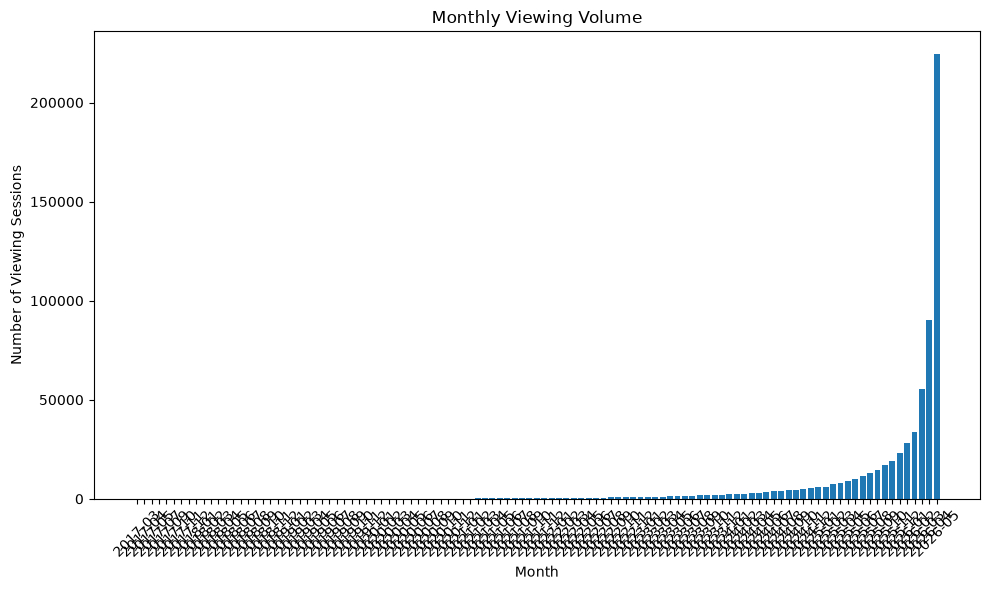

In [73]:
plt.figure(figsize=(10,6))

plt.bar(monthly_viewing["month"].astype(str),
        monthly_viewing["sessions"])

plt.title("Monthly Viewing Volume")
plt.xlabel("Month")
plt.ylabel("Number of Viewing Sessions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
busiest = monthly_viewing.loc[
    monthly_viewing["sessions"].idxmax()
]

print("Busiest Month:", busiest["month"])
print("Viewing Sessions:", busiest["sessions"])


Busiest Month: 2026-05
Viewing Sessions: 224696


#The monthly viewing volume chart shows the total number of viewing sessions for each month throughout the dataset. The busiest month was May with 224696 viewing sessions, indicating the highest level of user engagement. Viewing activity varies across the timeline, suggesting possible seasonal trends or changes in content popularity.

In [8]:
#2
watch_history["watch_hours"] = watch_history["watch_duration_min"] / 60

In [9]:
watch_history["watch_date"] = pd.to_datetime(watch_history["watch_date"])

watch_history["month"] = watch_history["watch_date"].dt.to_period("M")

In [10]:
monthly_hours = (
    watch_history.groupby("month")["watch_hours"]
    .sum()
    .reset_index()
)

print(monthly_hours)

       month   watch_hours
0    2017-03  4.773333e+00
1    2017-04  4.400000e+00
2    2017-05  1.441667e+01
3    2017-07  1.413333e+00
4    2017-09  2.610000e+00
..       ...           ...
104  2026-01  1.435220e+05
105  2026-02  1.745655e+05
106  2026-03  2.860884e+05
107  2026-04  4.633373e+05
108  2026-05  1.157786e+06

[109 rows x 2 columns]


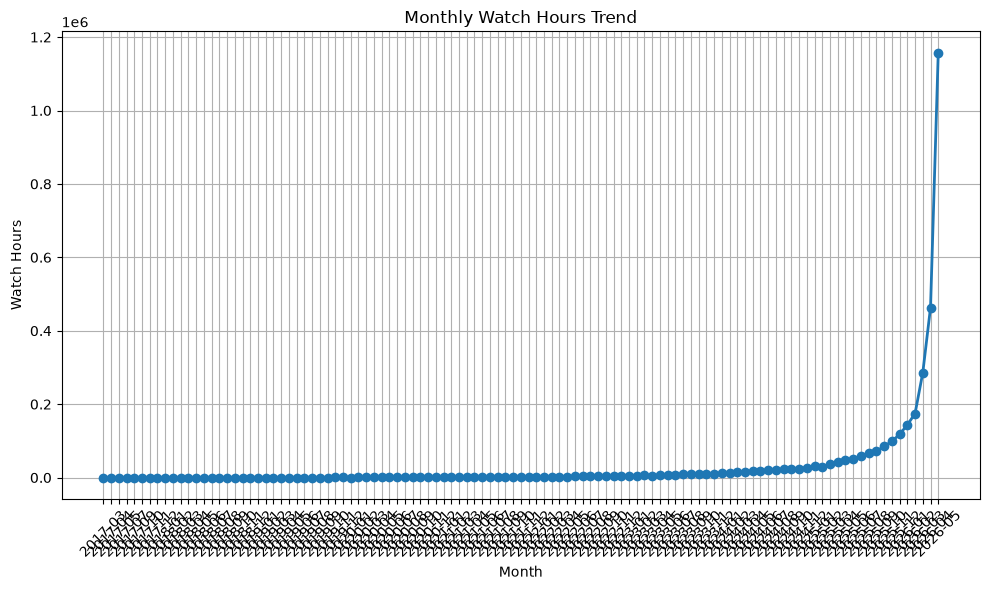

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    monthly_hours["month"].astype(str),
    monthly_hours["watch_hours"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Watch Hours Trend")
plt.xlabel("Month")
plt.ylabel("Watch Hours")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.show()

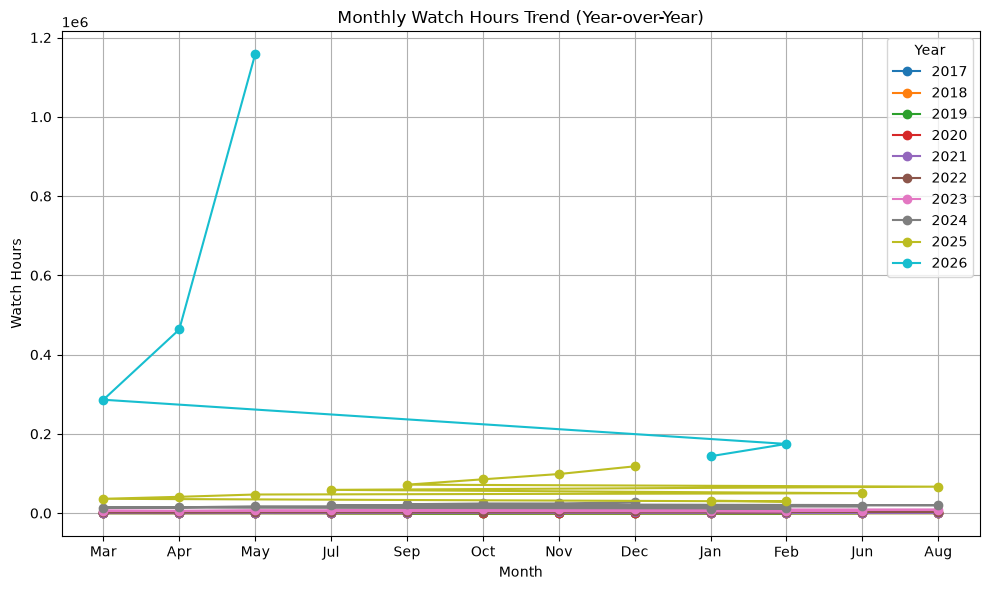

In [70]:
watch_history["year"] = watch_history["watch_date"].dt.year
watch_history["month_name"] = watch_history["watch_date"].dt.strftime("%b")

monthly_yoy = (
    watch_history.groupby(["year", "month_name"])["watch_hours"]
    .sum()
    .reset_index()
)

# Ensure months appear in calendar order
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

monthly_yoy["month_name"] = pd.Categorical(
    monthly_yoy["month_name"],
    categories=month_order,
    ordered=True
)

monthly_yoy = monthly_yoy.sort_values(["year", "month_name"])

plt.figure(figsize=(10,6))

for year in monthly_yoy["year"].unique():
    data = monthly_yoy[monthly_yoy["year"] == year]
    plt.plot(
        data["month_name"],
        data["watch_hours"],
        marker="o",
        label=year
    )
    plt.title("Monthly Watch Hours Trend (Year-over-Year)")
plt.xlabel("Month")
plt.ylabel("Watch Hours")
plt.legend(title="Year")
plt.grid(True)

plt.tight_layout()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.show()

The monthly watch hours trend illustrates how total viewing time changes throughout the year. Comparing the yearly lines helps identify whether viewer engagement has increased or decreased over time, as well as recurring seasonal peaks and dips. Months with the highest watch hours indicate periods of greater user activity and content consumption.

In [14]:
#3

genre_watch = watch_history.merge(
    titles[['title_id', 'primary_genre']],
    on='title_id',
    how='left'
)


In [15]:
genre_watch['watch_hours'] = genre_watch['watch_duration_min'] / 60

In [17]:
genre_hours = (
    genre_watch.groupby('primary_genre')['watch_hours']
    .sum()
    .sort_values(ascending=False)
)

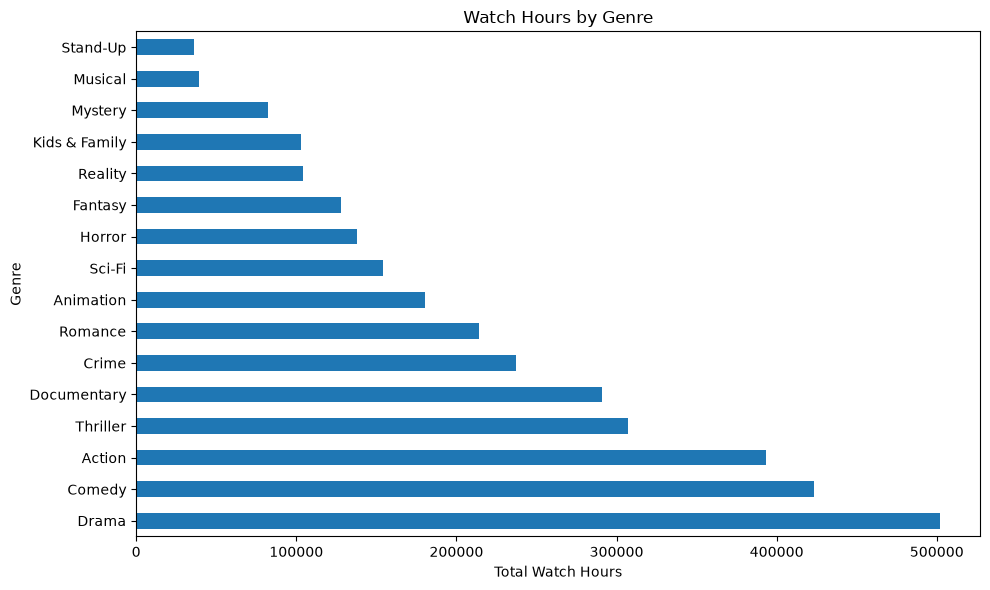

In [69]:
plt.figure(figsize=(10,6))
genre_hours.plot(kind='barh')

plt.title('Watch Hours by Genre')
plt.xlabel('Total Watch Hours')
plt.ylabel('Genre')

plt.tight_layout()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
top_genre = genre_hours.idxmax()
top_hours = genre_hours.max()

print(f"Top Genre: {top_genre}")
print(f"Total Watch Hours: {top_hours:.2f}")

Top Genre: Drama
Total Watch Hours: 501884.47


The Drama genre accumulated the highest total watch hours, indicating that viewers spent more time watching this genre than any other. Genres with lower watch hours may represent niche audience interests or a smaller content library.

In [21]:
#4

content_watch = watch_history.merge(
    titles[['title_id', 'type']],
    on='title_id',
    how='left'
)

In [22]:
content_watch['watch_hours'] = content_watch['watch_duration_min'] / 60

In [26]:
content_hours = (
    content_watch.groupby('type')['watch_hours']
    .sum()
)
content_hours

type
Movie      4.508588e+05
TV Show    2.882609e+06
Name: watch_hours, dtype: float64

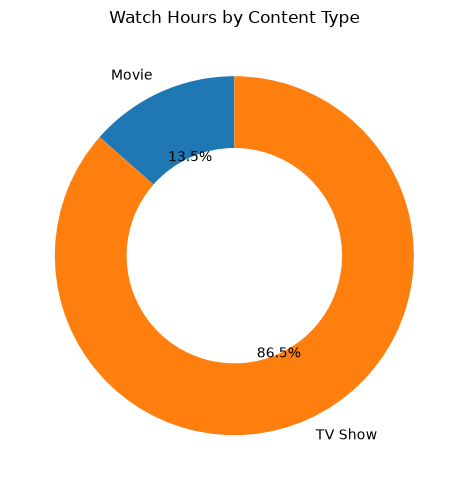

In [68]:
plt.figure(figsize=(5,5))

plt.pie(
    content_hours,
    labels=content_hours.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.title('Watch Hours by Content Type')
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [29]:
top_type = content_hours.idxmax()
top_hours = content_hours.max()

print("Most Watched Content Type:", top_type)
print(f"Total Watch Hours: {top_hours:.2f}")

Most Watched Content Type: TV Show
Total Watch Hours: 2882608.92


TV Shows accounted for the largest share of total watch hours, indicating that subscribers spend more time watching episodic content than movies. Movies contributed a smaller share of viewing hours, reflecting their shorter average duration.

In [30]:
#5

watch_history['watch_hours'] = watch_history['watch_duration_min'] / 60

In [31]:
top_countries = (
    watch_history.groupby('region')['watch_hours']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

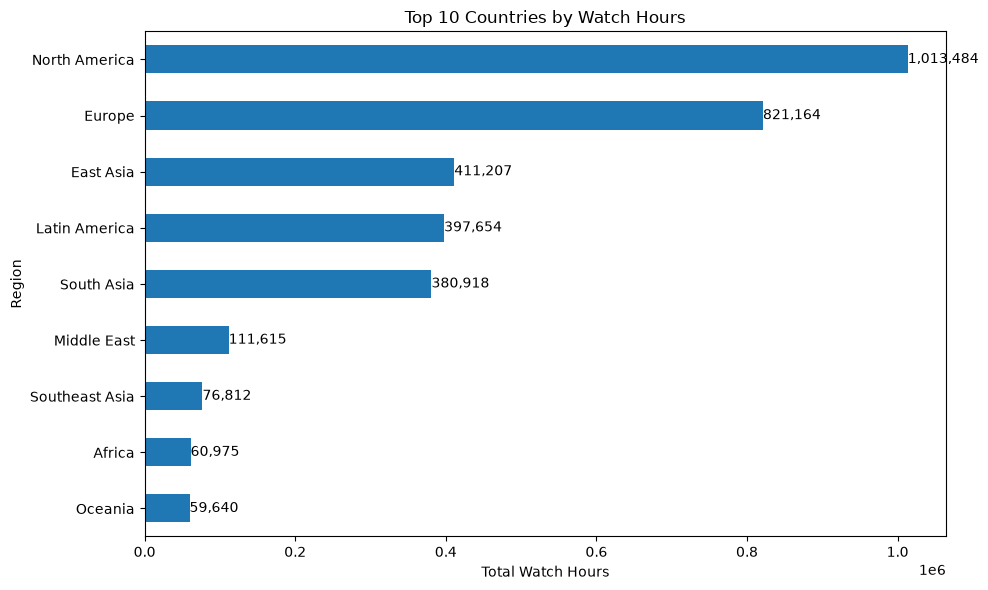

In [67]:
plt.figure(figsize=(10,6))

top_countries.plot(kind='barh')

plt.title('Top 10 Countries by Watch Hours')
plt.xlabel('Total Watch Hours')
plt.ylabel('Region')

# Display values on the bars
for i, value in enumerate(top_countries):
    plt.text(value, i, f'{value:,.0f}', va='center')

# Highest value at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
print("Top Country:", top_countries.idxmax())
print("Watch Hours:", round(top_countries.max(), 2))

Top Country: North America
Watch Hours: 1013483.83


North America recorded the highest total watch hours among all regions, indicating the strongest viewer engagement. The remaining regions showed progressively lower watch hours, with the top 10 accounting for the majority of total viewing activity.

In [36]:
#6

plan_counts = (
    subscribers['plan_type']
    .value_counts()
)
print(plan_counts)

plan_type
Standard          6100
Basic with Ads    4458
Premium           4442
Name: count, dtype: int64


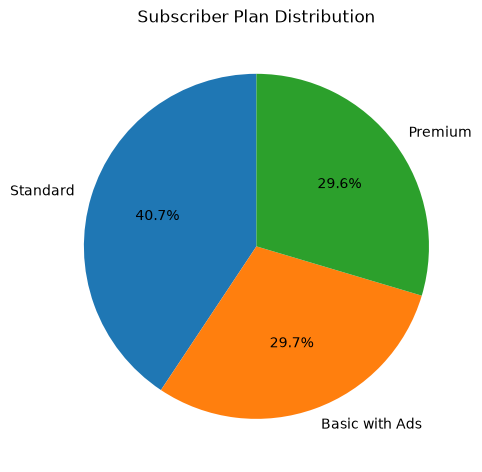

In [65]:
plt.figure(figsize=(5,5))

plt.pie(
    plan_counts,
    labels=plan_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Subscriber Plan Distribution')

plt.tight_layout()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.show()

Standard had the highest number of subscribers, followed by Basic, while Premium had the fewest subscribers. This suggests that a larger share of users prefer higher-tier subscription plans for additional features and benefits.

In [40]:
#7

device_usage = (
    watch_history['device']
    .value_counts()
)
print(device_usage)

device
Smart TV           221446
Mobile             175605
Laptop              96408
Tablet              65276
Game Console        52322
Streaming Stick     38943
Name: count, dtype: int64


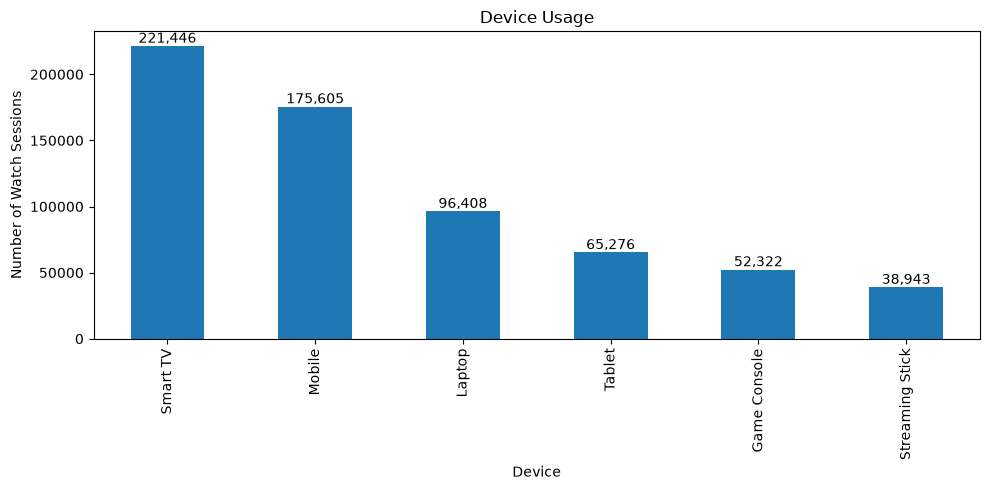

In [66]:
plt.figure(figsize=(10,5))

device_usage.plot(kind='bar')

plt.title('Device Usage')
plt.xlabel('Device')
plt.ylabel('Number of Watch Sessions')

# Add value labels on top of bars
for i, value in enumerate(device_usage):
    plt.text(i, value, f'{value:,}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.show()

Smart TV recorded the highest number of watch sessions, making it the most frequently used device for streaming. Mobile and Laptop followed, while Tablet had the lowest usage, indicating that viewers generally prefer larger screens for watching content.

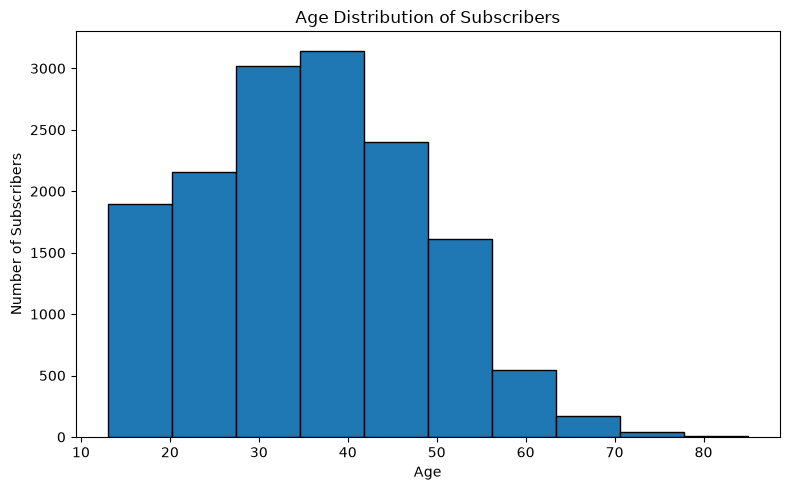

<Figure size 640x480 with 0 Axes>

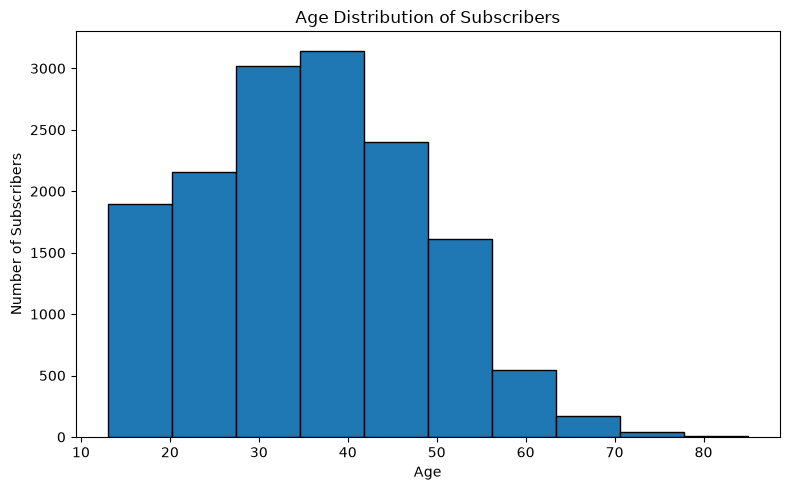

In [60]:
#8
plt.figure(figsize=(8,5))

plt.hist(subscribers['age'], bins=10, edgecolor='black')

plt.title('Age Distribution of Subscribers')
plt.xlabel('Age')
plt.ylabel('Number of Subscribers')

plt.tight_layout()
plt.show()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.figure(figsize=(8,5))

plt.hist(subscribers['age'], bins=10, edgecolor='black')

plt.title('Age Distribution of Subscribers')
plt.xlabel('Age')
plt.ylabel('Number of Subscribers')

plt.tight_layout()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
age_groups = (
    subscribers.groupby(
        pd.cut(subscribers['age'], bins=10)
    ).size()
)

print(age_groups)

age
(12.928, 20.2]    1897
(20.2, 27.4]      2159
(27.4, 34.6]      3023
(34.6, 41.8]      3144
(41.8, 49.0]      2691
(49.0, 56.2]      1317
(56.2, 63.4]       548
(63.4, 70.6]       174
(70.6, 77.8]        39
(77.8, 85.0]         8
dtype: int64


Subscribers aged 34–41 represent the largest age group, indicating that adults make up the majority of the platform's user base. Subscriber counts gradually decline in the older age groups, suggesting lower engagement among older audiences.

In [47]:
#9

genre_completion = watch_history.merge(
    titles[['title_id', 'primary_genre']],
    on='title_id',
    how='left'
)
completion_rate = (
    genre_completion.groupby('primary_genre')['completed']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

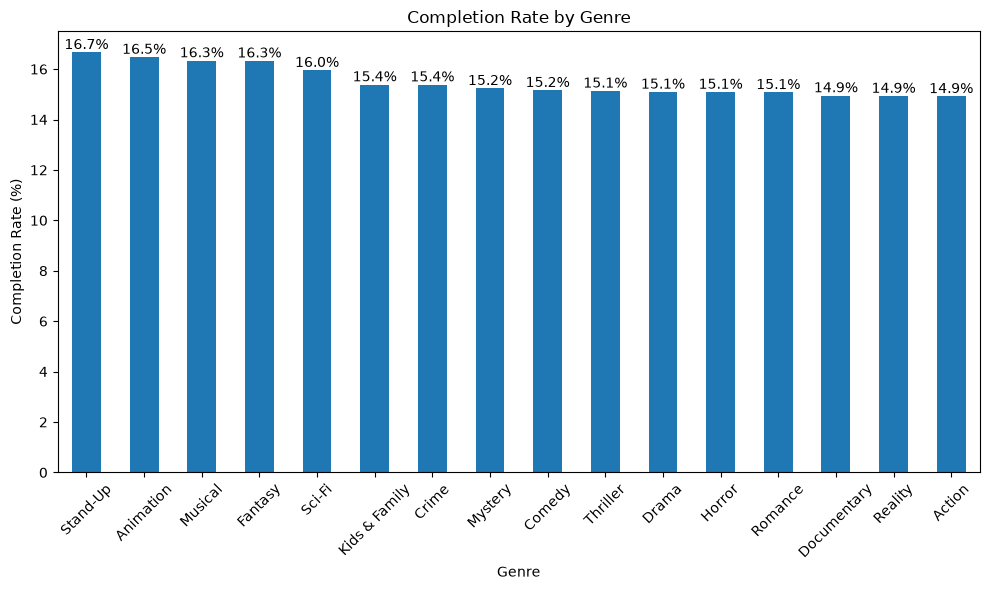

In [59]:
plt.figure(figsize=(10,6))

completion_rate.plot(kind='bar')

plt.title('Completion Rate by Genre')
plt.xlabel('Genre')
plt.ylabel('Completion Rate (%)')

# Display percentage labels
for i, value in enumerate(completion_rate):
    plt.text(i, value, f'{value:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
print("Highest Completion Rate Genre:", completion_rate.idxmax())
print(f"Completion Rate: {completion_rate.max():.2f}%")

Highest Completion Rate Genre: Stand-Up
Completion Rate: 16.66%


Stand-Up recorded the highest completion rate, indicating that viewers are more likely to finish content in this genre. Genres with lower completion rates may have longer content durations or lower viewer engagement, leading to more incomplete viewing sessions.

In [51]:
#10

sentiment_counts = (
    reviews['sentiment']
    .value_counts()
)
print(sentiment_counts)

sentiment
Positive    75007
Neutral     22759
Negative    12234
Name: count, dtype: int64


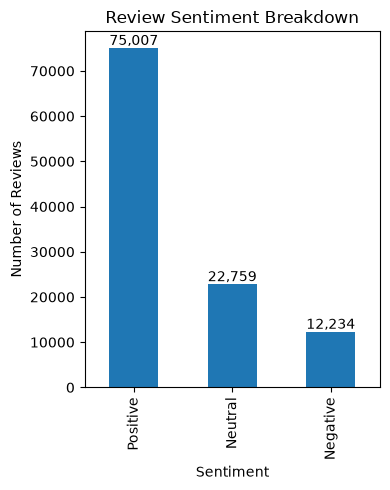

In [58]:
plt.figure(figsize=(4,5))

sentiment_counts.plot(kind='bar')

plt.title('Review Sentiment Breakdown')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

# Display values on top of the bars
for i, value in enumerate(sentiment_counts):
    plt.text(i, value, f'{value:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('device_usage.png', dpi=300, bbox_inches='tight')
plt.show()

Positive reviews make up the largest share of all reviews, indicating that users are generally satisfied with the content on the platform. Neutral reviews are the second most common, while Negative reviews are the fewest, suggesting overall favorable viewer sentiment.